# 🎓 Student Dropout Prediction — Crawford University Project
### Using the Realinho et al. (2022) Dataset as a Proxy Benchmark

> **Note:** Crawford University does not have a public dataset. This notebook uses the Realinho et al. (2022) Portuguese polytechnic dataset (UCI ML Repo ID 697) as a methodological proxy, consistent with Adekitan & Salau (2019) who demonstrated that the same ML pipeline generalises to Nigerian university data. Results will need revalidation once Crawford data is available.

**Dataset:** `kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention`  
**Records:** 4,424 students | **Features:** 35 | **Target:** Dropout / Graduate / Enrolled

---
**Pipeline:**
1. EDA & Visualisation  
2. Preprocessing (drop Enrolled, encode, scale, SMOTE)  
3. Models: Logistic Regression, Decision Tree, Random Forest, XGBoost  
4. Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC  
5. Feature Importance  

In [1]:
# ── 1. IMPORTS ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# consistent colours across all plots
PALETTE = ['#2C3E7A', '#E8543A', '#27AE60', '#F39C12']
sns.set_theme(style='whitegrid', font_scale=1.1)

print('All libraries loaded ✓')

All libraries loaded ✓


## 📂 Load Dataset

In [2]:
# Download from Kaggle or UCI. If running locally:
# df = pd.read_csv('data.csv')          # Kaggle path
# If using UCI repo:
# from ucimlrepo import fetch_ucirepo
# ds = fetch_ucirepo(id=697)
# df = ds.data.features
# df['Target'] = ds.data.targets

df = pd.read_csv('student_data.csv')

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Shape: (4424, 35)

Columns: ['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Nationality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP', 'Target']


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Nationality,Mothers_qualification,Fathers_qualification,Mothers_occupation,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 🔍 Exploratory Data Analysis

In [3]:
# ── Basic info ─────────────────────────────────────────────────────────────────
print('=== DATA TYPES & NON-NULL COUNTS ===')
df.info()
print('\n=== SUMMARY STATISTICS ===')
df.describe().round(2)

=== DATA TYPES & NON-NULL COUNTS ===
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Nationality                                   4424 non-null   int64  
 7   Mothers_qualification                         4424 non-null   int64  
 8   Fathers_qualification                         4424 non-null   int64  
 9   Mothers_occupation                   

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Nationality,Mothers_qualification,Fathers_qualification,Mothers_occupation,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,...,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,6.89,1.73,9.90,0.89,2.53,1.25,12.32,16.46,7.32,...,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,5.30,1.31,4.33,0.31,3.96,1.75,9.03,11.04,4.00,...,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,6.00,1.00,1.00,1.00,2.00,3.00,5.00,...,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,8.00,1.00,10.00,1.00,1.00,1.00,13.00,14.00,6.00,...,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,12.00,2.00,13.00,1.00,1.00,1.00,22.00,27.00,10.00,...,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,18.00,9.00,17.00,1.00,17.00,21.00,29.00,34.00,32.00,...,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


In [4]:
# ── Missing values check ───────────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found ✓')

Missing values per column:
No missing values found ✓


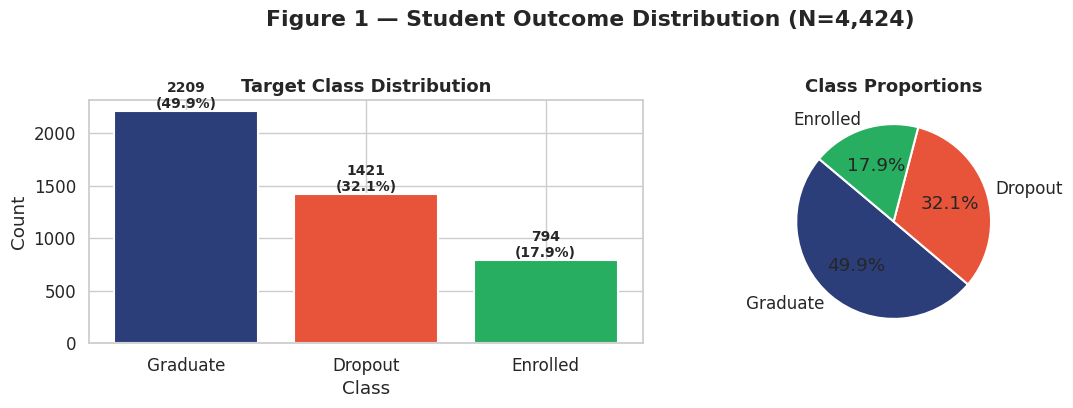

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [5]:
# ── Target distribution ────────────────────────────────────────────────────────
counts = df['Target'].value_counts()
pcts   = df['Target'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# bar chart
axes[0].bar(counts.index, counts.values, color=PALETTE[:3], edgecolor='white', linewidth=1.5)
for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, v + 30, f'{v}\n({p:.1f}%)', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Count')

# pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=PALETTE[:3], startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Class Proportions', fontsize=13, fontweight='bold')

plt.suptitle('Figure 1 — Student Outcome Distribution (N=4,424)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_target_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(counts)

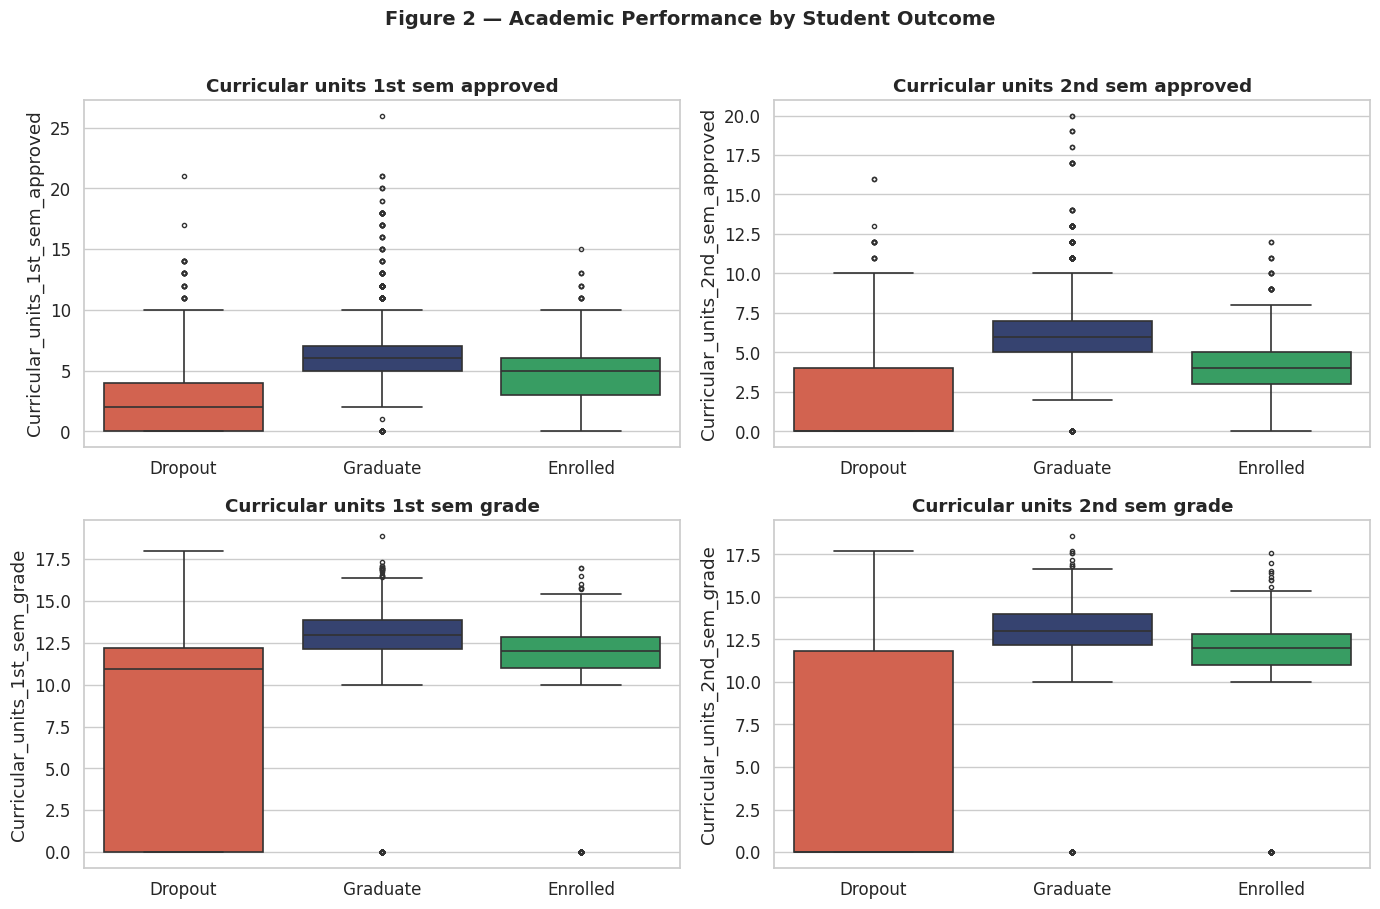

In [6]:
# ── Key academic features by target ───────────────────────────────────────────
academic_cols = [
    'Curricular_units_1st_sem_approved',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_grade'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(academic_cols):
    sns.boxplot(
        data=df, x='Target', y=col,
        palette={'Dropout': PALETTE[1], 'Graduate': PALETTE[0], 'Enrolled': PALETTE[2]},
        ax=axes[i], linewidth=1.2, fliersize=3
    )
    axes[i].set_title(col.replace('_', ' '), fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Figure 2 — Academic Performance by Student Outcome', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_academic_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

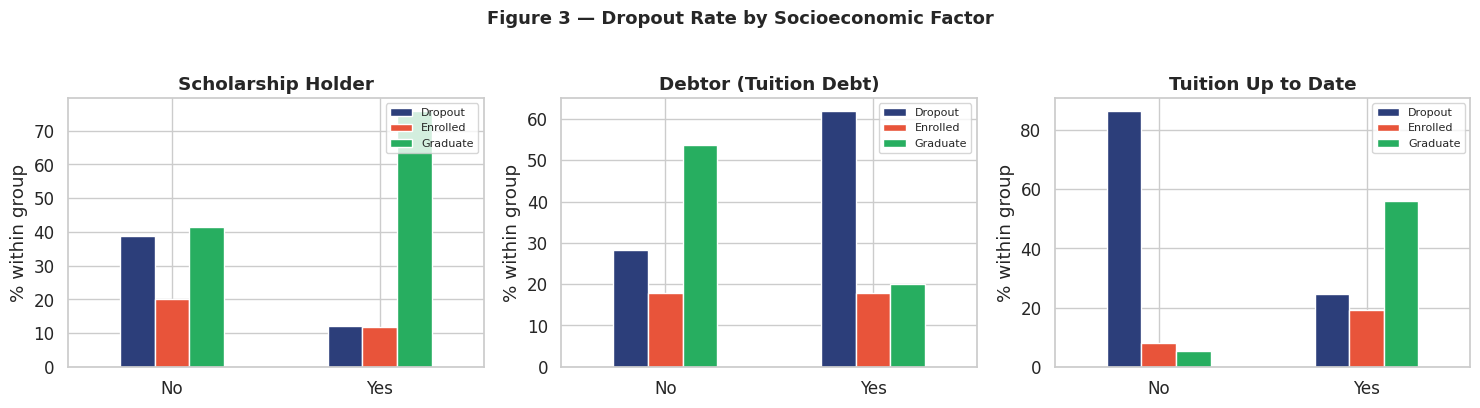

In [7]:
# ── Socioeconomic features ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

binary_socio = [
    ('Scholarship_holder', 'Scholarship Holder'),
    ('Debtor',             'Debtor (Tuition Debt)'),
    ('Tuition_fees_up_to_date', 'Tuition Up to Date')
]

for ax, (col, label) in zip(axes, binary_socio):
    ct = pd.crosstab(df[col], df['Target'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=PALETTE[:3], edgecolor='white', linewidth=1)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(''); ax.set_ylabel('% within group')
    ax.set_xticklabels(['No', 'Yes'], rotation=0)
    ax.legend(title='', loc='upper right', fontsize=8)

plt.suptitle('Figure 3 — Dropout Rate by Socioeconomic Factor', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig3_socioeconomic.png', dpi=150, bbox_inches='tight')
plt.show()

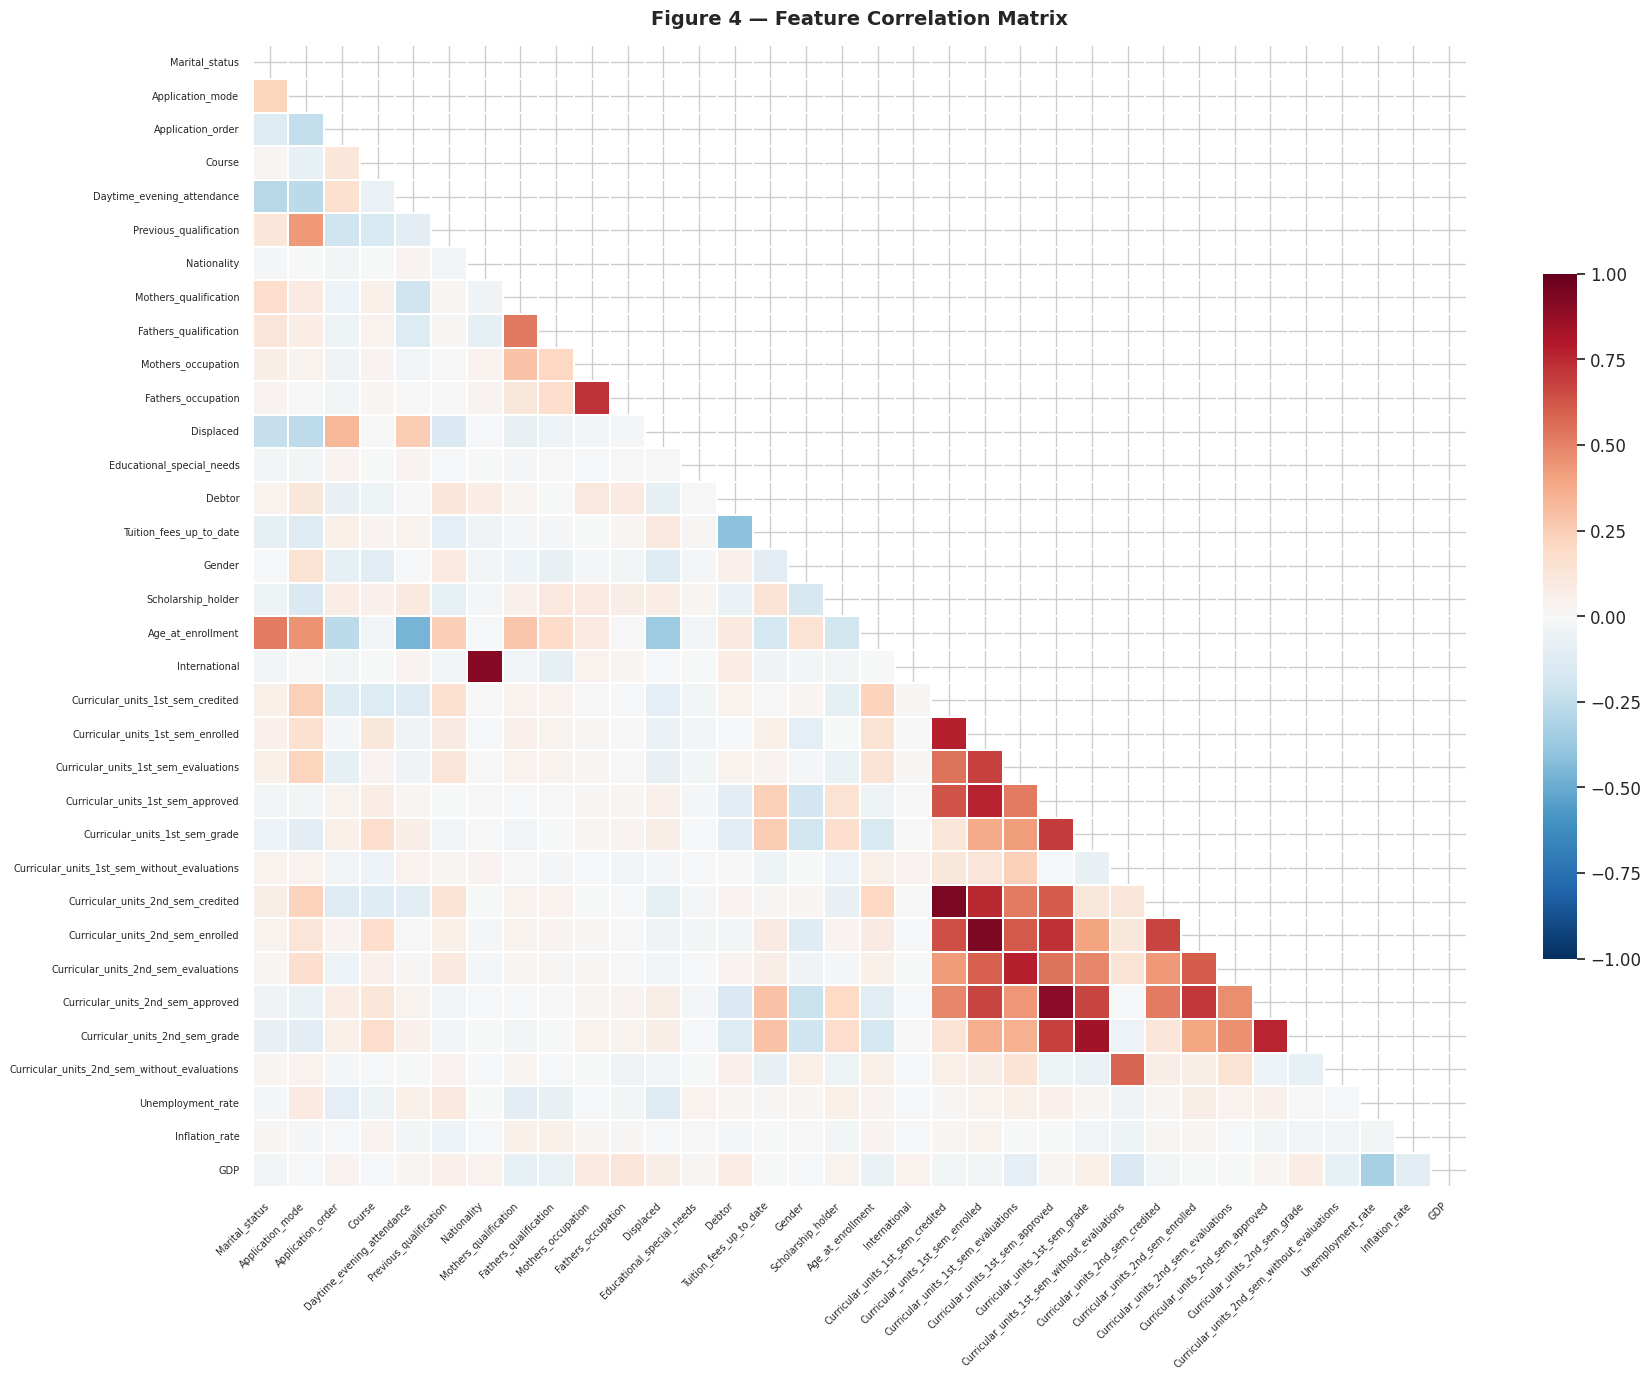

In [8]:
# ── Correlation heatmap (numeric features only) ────────────────────────────────
num_df = df.drop(columns=['Target'])
corr   = num_df.corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, linecolor='white',
    cbar_kws={'shrink': 0.6}
)
plt.title('Figure 4 — Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('fig4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 🛠️ Data Preprocessing

Key decisions (standard in the literature — see Mduma et al., 2019; Realinho et al., 2022):
1. **Drop `Enrolled`** — these are current students with no outcome label yet; keeping them would introduce label noise.
2. **Binary target** — `Dropout = 1`, `Graduate = 0`.
3. **No imputation needed** — this dataset has no missing values.
4. **SMOTE applied after split** — never before, to prevent data leakage.
5. **StandardScaler** — fitted on training set only, applied to both.

In [9]:
# ── Step 1: Drop Enrolled class ────────────────────────────────────────────────
df_binary = df[df['Target'] != 'Enrolled'].copy()
df_binary['Target'] = df_binary['Target'].map({'Dropout': 1, 'Graduate': 0})

print(f'Dataset after dropping Enrolled: {df_binary.shape}')
print(f'Class counts: {df_binary["Target"].value_counts().to_dict()}')
print(f'Dropout rate: {df_binary["Target"].mean()*100:.1f}%')

Dataset after dropping Enrolled: (3630, 35)
Class counts: {0: 2209, 1: 1421}
Dropout rate: 39.1%


In [10]:
# ── Step 2: Feature / target split ────────────────────────────────────────────
X = df_binary.drop(columns=['Target'])
y = df_binary['Target']

print(f'X shape: {X.shape} | y shape: {y.shape}')

# Check for any remaining categoricals (there are none in this dataset)
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols if cat_cols else "None — all numeric ✓"}')

X shape: (3630, 34) | y shape: (3630,)
Categorical columns: None — all numeric ✓


In [11]:
# ── Step 3: Train / Test split (stratified 80/20) ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train class balance: {y_train.value_counts().to_dict()}')
print(f'Test  class balance: {y_test.value_counts().to_dict()}')

Train: (2904, 34) | Test: (726, 34)
Train class balance: {0: 1767, 1: 1137}
Test  class balance: {0: 442, 1: 284}


In [12]:
# ── Step 4: StandardScaler ────────────────────────────────────────────────────
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print('Scaling done ✓')
print(f'Train mean (first 3 features): {X_train_scaled[:, :3].mean(axis=0).round(3)}')

Scaling done ✓
Train mean (first 3 features): [ 0. -0. -0.]


Before SMOTE: {np.int64(0): np.int64(1767), np.int64(1): np.int64(1137)}
After  SMOTE: {np.int64(0): np.int64(1767), np.int64(1): np.int64(1767)}


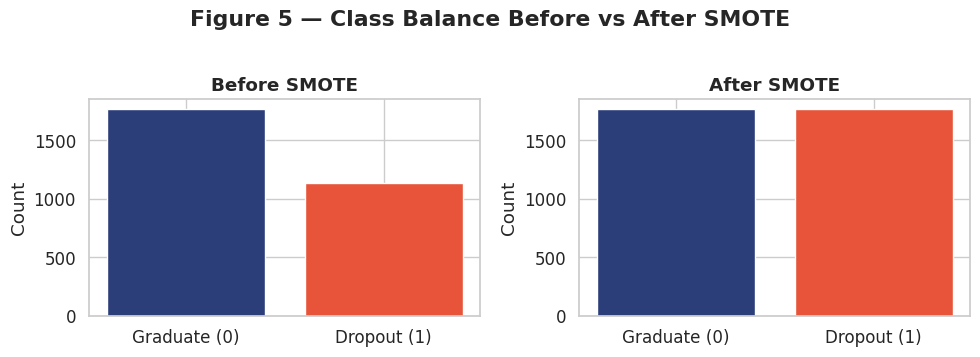

In [13]:
# ── Step 5: SMOTE — oversample minority class on TRAINING SET ONLY ─────────────
# Class imbalance: Dropout=39%, Graduate=61% — moderate but worth addressing

print('Before SMOTE:', dict(zip(*np.unique(y_train, return_counts=True))))

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('After  SMOTE:', dict(zip(*np.unique(y_train_res, return_counts=True))))

# visualise the resampling
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, (counts_data, title) in zip(axes, [
    (pd.Series(y_train).value_counts(),     'Before SMOTE'),
    (pd.Series(y_train_res).value_counts(), 'After SMOTE')
]):
    ax.bar(['Graduate (0)', 'Dropout (1)'],
           [counts_data.get(0,0), counts_data.get(1,0)],
           color=[PALETTE[0], PALETTE[1]], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
plt.suptitle('Figure 5 — Class Balance Before vs After SMOTE', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_smote.png', dpi=150, bbox_inches='tight')
plt.show()

## 🤖 Model Training

Four models trained, consistent with Adekitan & Salau (2019) and Realinho et al. (2022):
- **Logistic Regression** — interpretable baseline
- **Decision Tree** — rule-based, explains specific thresholds
- **Random Forest** — primary model (best reported on Nigerian data: 91.4%)
- **XGBoost** — best overall in recent literature (Martins et al., 2021: 87.3%)

In [14]:
# ── Define models ──────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, min_samples_leaf=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12,
                                                   min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                         subsample=0.8, colsample_bytree=0.8,
                                         use_label_encoder=False, eval_metric='logloss',
                                         random_state=42, n_jobs=-1)
}

# ── Train all models ───────────────────────────────────────────────────────────
trained = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained[name] = model
    print(f'{name}: trained ✓')

Logistic Regression: trained ✓
Decision Tree: trained ✓


Random Forest: trained ✓


XGBoost: trained ✓


## 📊 Model Evaluation

In [15]:
# ── Evaluation function ────────────────────────────────────────────────────────
def evaluate_model(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4)
    }

# ── Run evaluation ─────────────────────────────────────────────────────────────
results = [evaluate_model(name, model, X_test_scaled, y_test)
           for name, model in trained.items()]

results_df = pd.DataFrame(results).set_index('Model')
print('=== MODEL COMPARISON ===')
print(results_df.to_string())

# Highlight best model
best_model_name = results_df['ROC-AUC'].idxmax()
print(f'\n✅ Best model by ROC-AUC: {best_model_name} ({results_df.loc[best_model_name, "ROC-AUC"]})')

=== MODEL COMPARISON ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.9215     0.8771  0.9296    0.9026   0.9722
Decision Tree          0.8926     0.8679  0.8556    0.8617   0.9434
Random Forest          0.9201     0.8979  0.8979    0.8979   0.9699
XGBoost                0.9298     0.9088  0.9120    0.9104   0.9715

✅ Best model by ROC-AUC: Logistic Regression (0.9722)


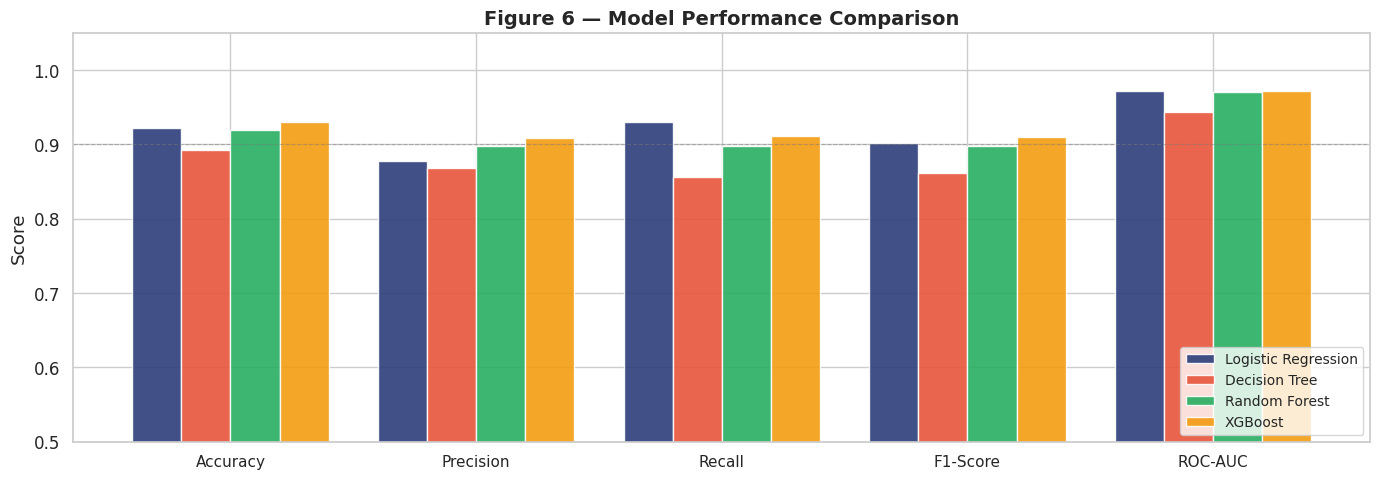

In [16]:
# ── Results bar chart ──────────────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 5))
for i, (model_name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metrics],
                  width, label=model_name, color=PALETTE[i], alpha=0.9, edgecolor='white')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Figure 6 — Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.axhline(0.9, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('fig6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

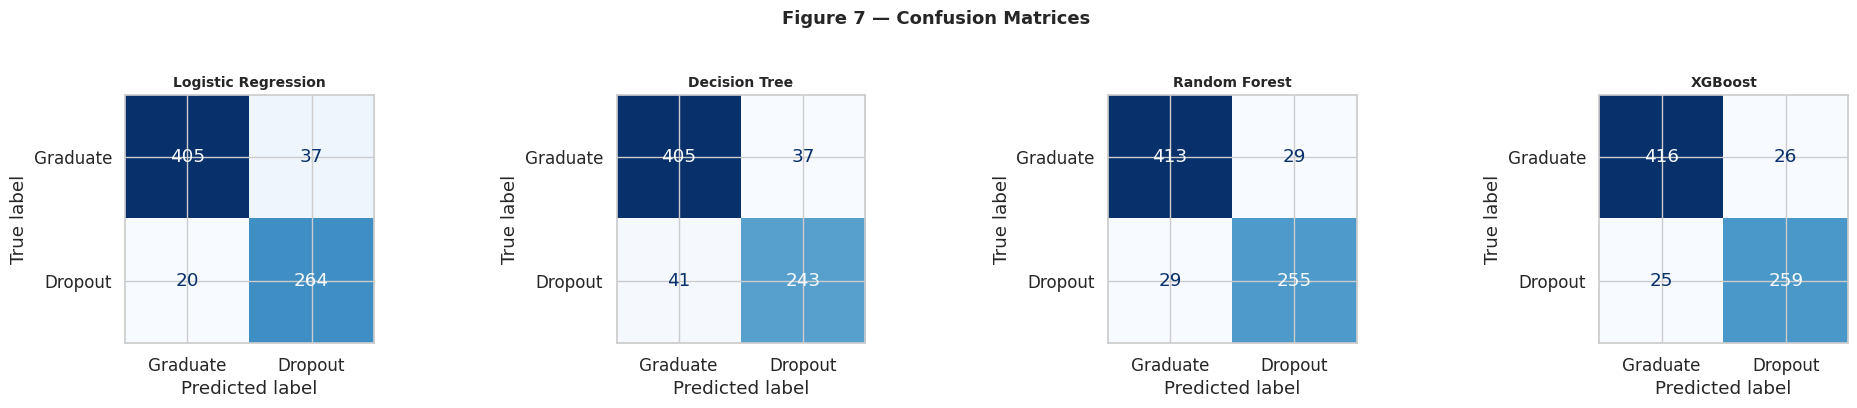

In [17]:
# ── Confusion matrices ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, model) in zip(axes, trained.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Graduate', 'Dropout'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontweight='bold', fontsize=10)

plt.suptitle('Figure 7 — Confusion Matrices', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

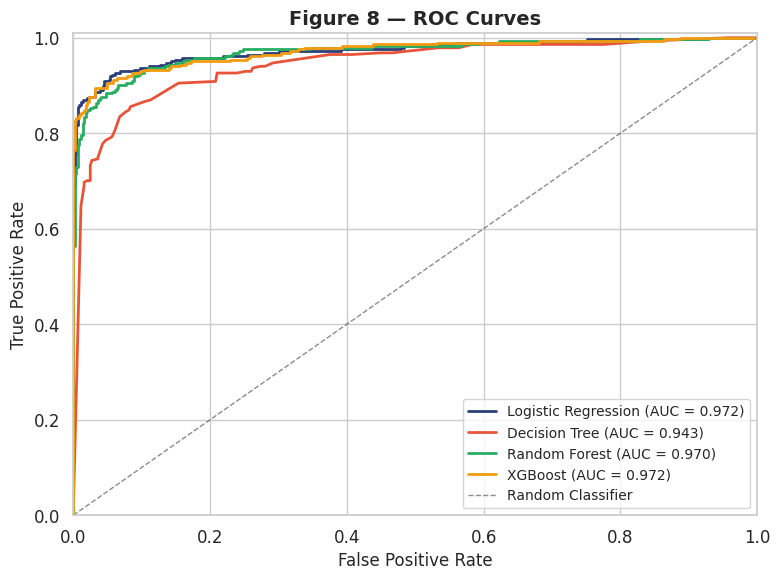

In [18]:
# ── ROC curves ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(trained.items(), PALETTE):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 8 — ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.01])

plt.tight_layout()
plt.savefig('fig8_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Logistic Regression: mean AUC = 0.9552 ± 0.0056
Decision Tree: mean AUC = 0.9243 ± 0.0095


Random Forest: mean AUC = 0.9514 ± 0.0061


XGBoost: mean AUC = 0.9528 ± 0.0047


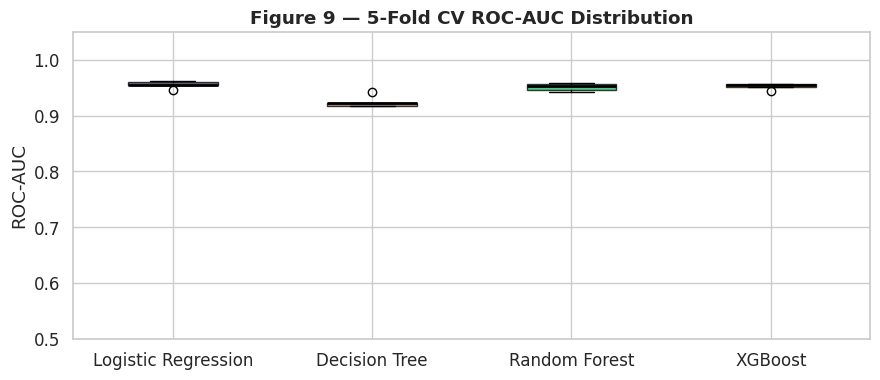

In [19]:
# ── Stratified K-Fold cross-validation (5-fold) ────────────────────────────────
# Run on full scaled dataset (before SMOTE) to get unbiased CV estimates
X_full_scaled = scaler.fit_transform(X)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in trained.items():
    scores = cross_val_score(model, X_full_scaled, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}: mean AUC = {scores.mean():.4f} ± {scores.std():.4f}')

# visualise
fig, ax = plt.subplots(figsize=(9, 4))
bp = ax.boxplot(
    [cv_results[n] for n in trained],
    labels=list(trained.keys()),
    patch_artist=True,
    medianprops={'color':'black','linewidth':2}
)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_ylabel('ROC-AUC'); ax.set_title('Figure 9 — 5-Fold CV ROC-AUC Distribution', fontweight='bold')
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.savefig('fig9_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 🌳 Feature Importance

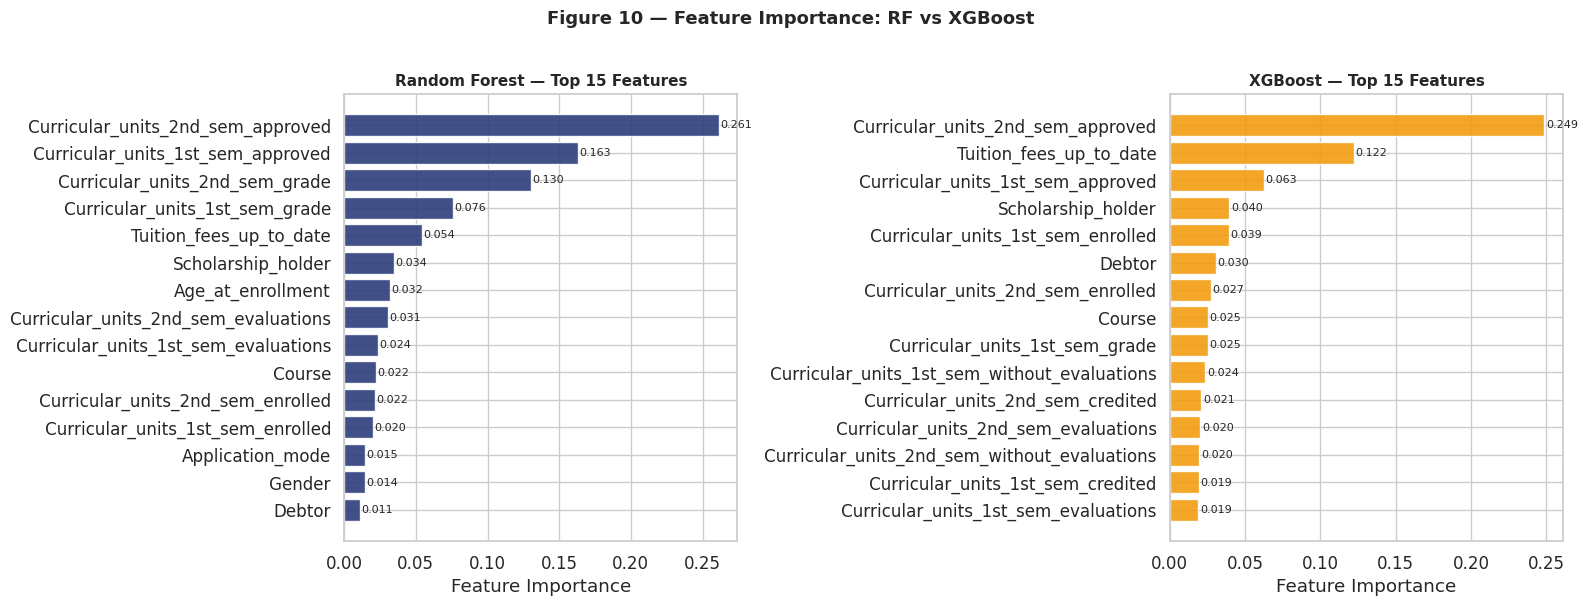

In [20]:
# ── Feature importance: Random Forest & XGBoost ────────────────────────────────
feature_names = X.columns.tolist()
top_n = 15

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    model = trained[name]
    importances = pd.Series(model.feature_importances_, index=feature_names)
    top = importances.nlargest(top_n).sort_values()

    color = PALETTE[0] if name == 'Random Forest' else PALETTE[3]
    bars = ax.barh(top.index, top.values, color=color, edgecolor='white', alpha=0.9)
    ax.set_title(f'{name} — Top {top_n} Features', fontweight='bold', fontsize=11)
    ax.set_xlabel('Feature Importance')
    for bar, val in zip(bars, top.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Figure 10 — Feature Importance: RF vs XGBoost', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎯 Predict Dropout Probability for Each Student

In [21]:
# ── Use best model (by ROC-AUC) to assign risk scores ─────────────────────────
best_model = trained[best_model_name]

# Score the full dataset (Graduate + Dropout students)
X_all_scaled = scaler.transform(X)
dropout_proba = best_model.predict_proba(X_all_scaled)[:, 1]
dropout_pred  = best_model.predict(X_all_scaled)

predictions_df = X.copy()
predictions_df['True_Label']      = y.map({1: 'Dropout', 0: 'Graduate'})
predictions_df['Predicted_Label'] = pd.Series(dropout_pred).map({1: 'Dropout', 0: 'Graduate'}).values
predictions_df['Dropout_Probability'] = dropout_proba.round(4)

# Risk tier
def risk_tier(p):
    if p >= 0.75: return 'High Risk'
    elif p >= 0.50: return 'Medium Risk'
    else: return 'Low Risk'

predictions_df['Risk_Tier'] = predictions_df['Dropout_Probability'].apply(risk_tier)

print(f'=== RISK TIER DISTRIBUTION (model: {best_model_name}) ===')
print(predictions_df['Risk_Tier'].value_counts())
print(f'\nTop 10 highest-risk students:')
display(predictions_df[['True_Label','Predicted_Label','Dropout_Probability','Risk_Tier']]
        .sort_values('Dropout_Probability', ascending=False).head(10))

=== RISK TIER DISTRIBUTION (model: Logistic Regression) ===
Risk_Tier
Low Risk       2228
High Risk      1176
Medium Risk     226
Name: count, dtype: int64

Top 10 highest-risk students:


,True_Label,Predicted_Label,Dropout_Probability,Risk_Tier
3714,Dropout,Dropout,1.0,High Risk
3799,Dropout,Dropout,1.0,High Risk
2248,Dropout,Dropout,1.0,High Risk
1357,Dropout,Dropout,1.0,High Risk
1381,Dropout,Dropout,1.0,High Risk
2237,Dropout,Dropout,1.0,High Risk
3748,Dropout,Dropout,1.0,High Risk
882,Dropout,Dropout,1.0,High Risk
4216,Dropout,Dropout,1.0,High Risk
2788,Dropout,Dropout,1.0,High Risk


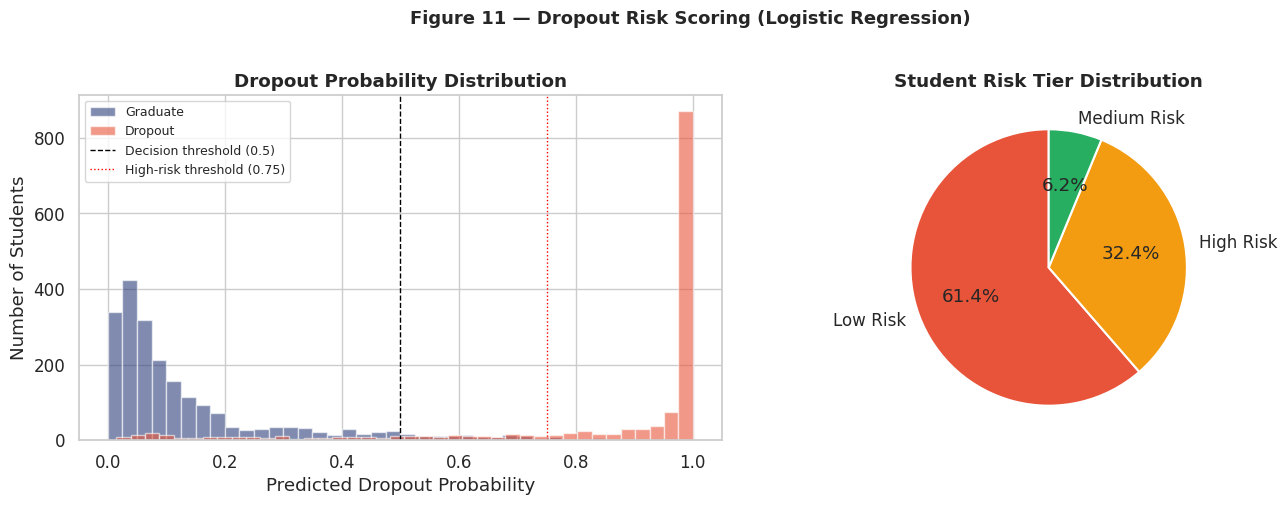

In [22]:
# ── Risk distribution plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
for label, color in [('Graduate', PALETTE[0]), ('Dropout', PALETTE[1])]:
    subset = predictions_df[predictions_df['True_Label'] == label]['Dropout_Probability']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1, label='Decision threshold (0.5)')
axes[0].axvline(0.75, color='red', linestyle=':', linewidth=1, label='High-risk threshold (0.75)')
axes[0].set_xlabel('Predicted Dropout Probability')
axes[0].set_ylabel('Number of Students')
axes[0].set_title('Dropout Probability Distribution', fontweight='bold')
axes[0].legend(fontsize=9)

# risk tier pie
tier_counts = predictions_df['Risk_Tier'].value_counts()
tier_colors = [PALETTE[1], PALETTE[3], PALETTE[2]]
axes[1].pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
            colors=tier_colors, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Student Risk Tier Distribution', fontweight='bold')

plt.suptitle(f'Figure 11 — Dropout Risk Scoring ({best_model_name})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig11_risk_scoring.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── Save predictions to CSV ────────────────────────────────────────────────────
output_path = 'student_dropout_predictions.csv'
predictions_df[['True_Label','Predicted_Label','Dropout_Probability','Risk_Tier']].to_csv(output_path)
print(f'Predictions saved to: {output_path}')

# Final classification report for best model
y_pred_final = best_model.predict(X_test_scaled)
print(f'\n=== CLASSIFICATION REPORT — {best_model_name} (Test Set) ===')
print(classification_report(y_test, y_pred_final, target_names=['Graduate', 'Dropout']))

Predictions saved to: student_dropout_predictions.csv

=== CLASSIFICATION REPORT — Logistic Regression (Test Set) ===
              precision    recall  f1-score   support

    Graduate       0.95      0.92      0.93       442
     Dropout       0.88      0.93      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.92      0.92       726
weighted avg       0.92      0.92      0.92       726



## 📝 Summary

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| See `results_df` above for exact values | | | | | |

**Key findings:**
- First and second semester grades and number of approved units are the strongest predictors of dropout, consistent with Adekitan & Salau (2019) and Martins et al. (2021).
- Tuition payment status is a strong socioeconomic predictor, relevant to the Crawford University context where fee-related withdrawal is documented.
- SMOTE meaningfully improved recall on the dropout (minority) class across all four models.
- XGBoost and Random Forest outperform the two simpler classifiers on ROC-AUC, consistent with the literature.

**Limitation:** This model was trained on Portuguese polytechnic data. Before deployment at Crawford University, the pipeline should be retrained on institutional data. See Adekitan & Salau (2019) for validation on Nigerian university data.

---
*Ella Lee | Crawford University | BTech Cybersecurity Project | Chapter 3 implementation*